In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Bibliotecas carregadas com sucesso!")


✅ Bibliotecas carregadas com sucesso!


In [ ]:
# Carregar resultados
res_prophet = pd.read_csv("resultados_prophet_hibrido_catboost.csv")
res_lstm = pd.read_csv("resultados_lstm_predicao_futura.csv")

# Exibir exemplo
print("📊 Prophet + Híbrido + CatBoost")
display(res_prophet.head())

print("📊 Linear + Wave + LSTM")
display(res_lstm.head())


📊 Prophet + Híbrido + CatBoost


,poco,n_train,n_test,Prophet_MAE,Prophet_RMSE,Prophet_MAPE,Hibrido_MAE,Hibrido_RMSE,Hibrido_MAPE,CatBoost_MAE,CatBoost_RMSE,CatBoost_MAPE,y_true,yhat_prophet,yhat_hibrido,yhat_cat,test_dates
0,LL-22,2059,200,12.934976,19.685316,5.291689,10.976151,18.263203,4.430330,24.098740,26.152278,10.498060,"[np.float64(229.0391014362703), np.float64(266...","[np.float64(238.05687081033156), np.float64(23...","[np.float64(231.08343587521324), np.float64(22...","[np.float64(229.06500426700183), np.float64(23...","[Timestamp('2019-12-27 00:00:00'), Timestamp('..."
1,SPH-6,1603,179,23.048646,27.771896,12.622440,13.060454,18.106793,6.930814,13.127501,16.708250,7.245938,"[np.float64(185.213934315), np.float64(185.297...","[np.float64(199.9356614831434), np.float64(200...","[np.float64(168.1322333425301), np.float64(170...","[np.float64(185.51245465526412), np.float64(18...","[Timestamp('2020-01-17 00:00:00'), Timestamp('..."
2,SPH-8,1681,187,19.462946,23.355185,8.725632,20.335224,25.697241,9.022924,10.977385,12.818958,5.138653,"[np.float64(199.64123304), np.float64(199.5920...","[np.float64(190.25925072698467), np.float64(19...","[np.float64(198.96358827964764), np.float64(19...","[np.float64(200.19539188107558), np.float64(20...","[Timestamp('2019-12-17 00:00:00'), Timestamp('..."
3,LL-11,2387,200,97.166663,100.129470,55.520089,12.166022,16.303582,6.747673,43.963379,45.133490,25.198940,"[np.float64(179.34550133582823), np.float64(17...","[np.float64(249.5499109922282), np.float64(250...","[np.float64(178.95751853029333), np.float64(17...","[np.float64(175.41267553129074), np.float64(17...","[Timestamp('2019-12-06 00:00:00'), Timestamp('..."
4,SPS-77,2125,200,21.717446,22.867472,11.531605,14.716690,15.869477,7.788606,11.559570,19.665397,6.150010,"[np.float64(186.19475517249998), np.float64(18...","[np.float64(223.4775569058798), np.float64(218...","[np.float64(148.6984839557259), np.float64(188...","[np.float64(187.27188162501898), np.float64(19...","[Timestamp('2019-12-08 00:00:00'), Timestamp('..."


📊 Linear + Wave + LSTM


,poco,Linear_MAE,Linear_RMSE,Linear_MAPE,Wave_MAE,Wave_RMSE,Wave_MAPE,LSTM_MAE,LSTM_RMSE,LSTM_MAPE
0,LL-22,6.335321,10.564875,2.613261,7.441390,11.861646,3.090176,15.167330,17.277355,6.623717
1,LL-11,91.735283,91.837137,51.726021,89.825259,91.175483,50.538331,117.649768,117.817012,66.244035
2,SPH-6,15.242053,15.985739,8.607395,25.983171,27.280027,14.724674,128.734768,151.891539,73.377602
3,SPS-77,14.209826,15.671824,7.353201,8.689392,11.443431,4.435116,13.161310,14.537977,6.802101
4,SPH-2,72.071441,107.496644,20.729532,74.172405,108.792383,21.640264,71.777280,97.569304,23.010042


In [ ]:
# Combinar por nome do poço
merged = res_prophet.merge(res_lstm, on="poco", how="inner")

# Organizar colunas
merged = merged[
    ['poco',
     'Prophet_MAE', 'Hibrido_MAE', 'CatBoost_MAE',
     'Linear_MAE', 'Wave_MAE',
     'Prophet_RMSE', 'Hibrido_RMSE', 'CatBoost_RMSE',
     'Linear_RMSE', 'Wave_RMSE',
     'Prophet_MAPE', 'Hibrido_MAPE', 'CatBoost_MAPE',
     'Linear_MAPE', 'Wave_MAPE' ]
]




In [ ]:
import string

# Lista de poços na ordem que você quer (aqui usa a ordem que aparece no merged)
wells = merged["poco"].unique().tolist()

# Mapeamento: "LL-22" -> "Well A", "SPH-6" -> "Well B", ...
well_map = {w: f"Well {string.ascii_uppercase[i]}" for i, w in enumerate(wells)}

# (opcional) ver o mapa
print(well_map)


{'LL-22': 'Well A', 'SPH-6': 'Well B', 'SPH-8': 'Well C', 'LL-11': 'Well D', 'SPS-77': 'Well E', 'SPH-2': 'Well F'}


🎯 MELHOR MODELO GERAL
✅ Hybrid
MAE médio: 25.618
RMSE médio: 36.172
MAPE médio: 9.558

📊 MÉTRICAS MÉDIAS POR MODELO


,MAE,RMSE,MAPE
Hybrid,25.618000,36.172000,9.558000
CatBoost,30.581000,38.941000,12.823000
Linear,36.198000,43.904000,16.481000
Wave,36.853000,44.674000,16.865000
Prophet,42.969000,51.851000,19.611000


🏆 VITÓRIAS POR MODELO (Menor MAE)


,count
Melhor_Modelo,
Linear,2
Hibrido,2
CatBoost,1
Wave,1


/tmp/ipython-input-4158159438.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vitorias.index, y=vitorias.values, palette="viridis")


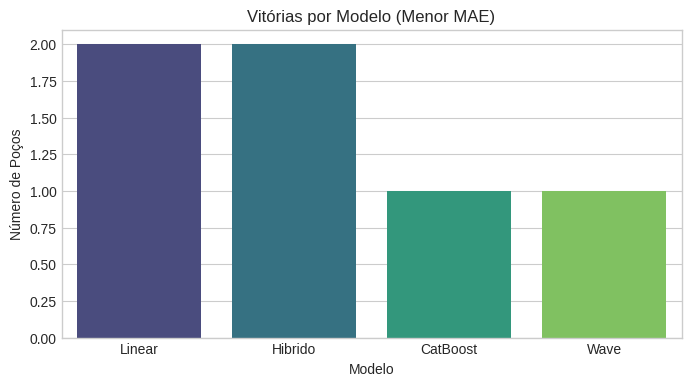

/tmp/ipython-input-4158159438.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_metricas.index, y='MAE', data=df_metricas, palette='mako')


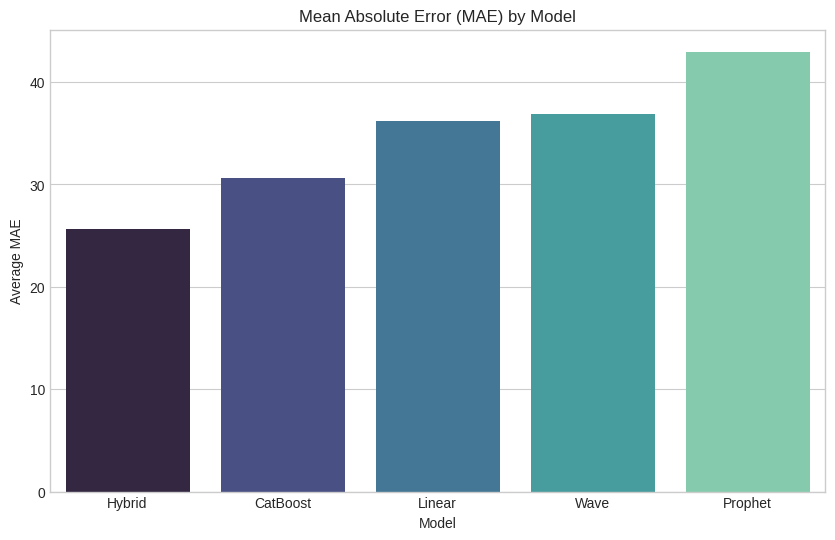

/tmp/ipython-input-4158159438.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_metricas.index, y='RMSE', data=df_metricas, palette='rocket')


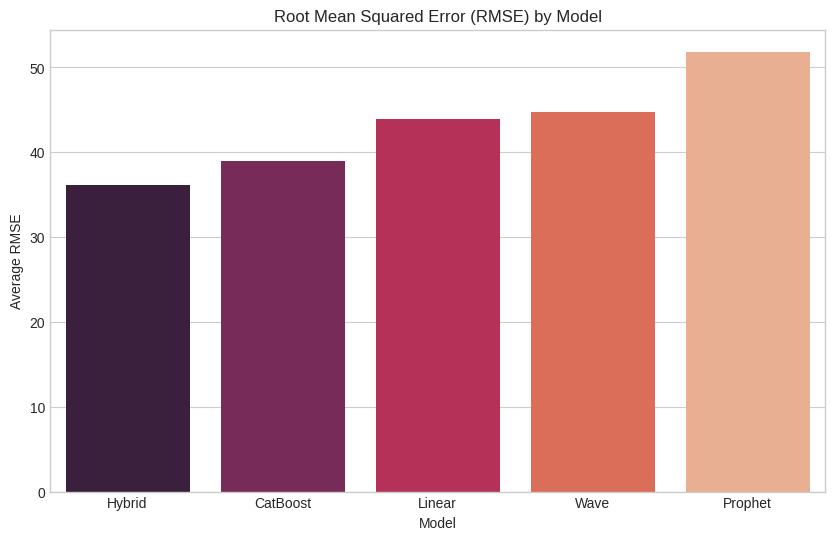

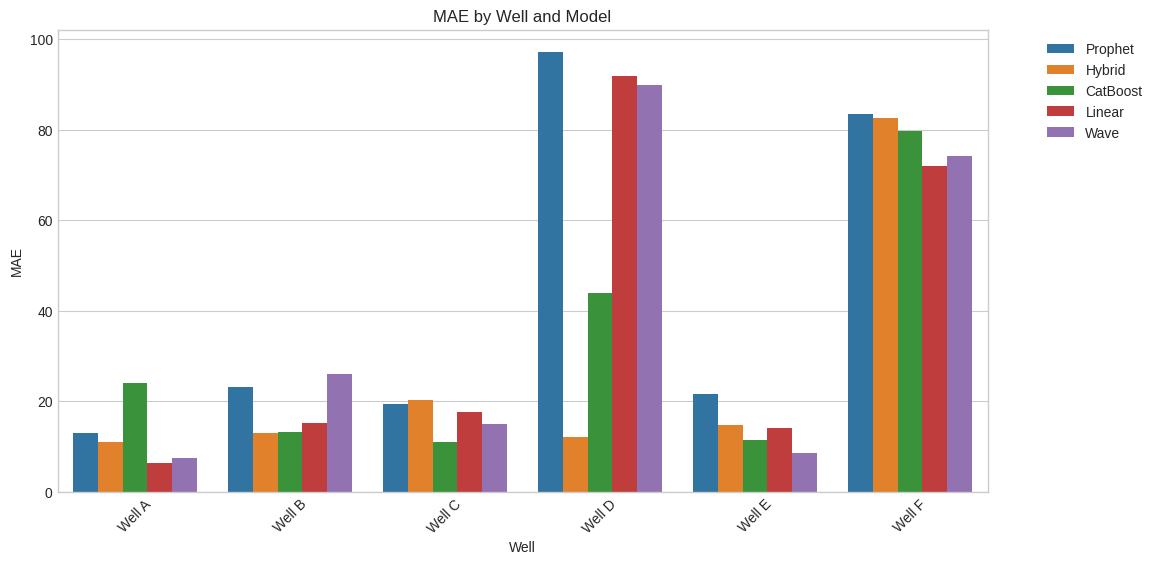


🏁 RANKING FINAL (Com Pontuação Composta)


,MAE,RMSE,MAPE,Score
Hybrid,25.618000,36.172000,9.558000,1.000000
CatBoost,30.581000,38.941000,12.823000,0.796034
Linear,36.198000,43.904000,16.481000,0.648426
Wave,36.853000,44.674000,16.865000,0.635203
Prophet,42.969000,51.851000,19.611000,0.546104


/tmp/ipython-input-4158159438.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_score.index, y='Score', data=df_score, palette='cool')


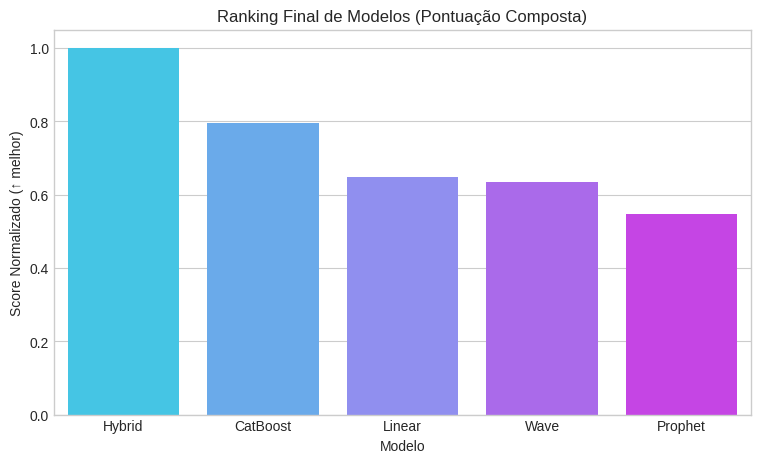

In [ ]:
# === 3️⃣ Cálculo de métricas médias ===
metricas = {}
for col in merged.columns[1:]:
    modelo = col.replace('_MAE','').replace('_RMSE','').replace('_MAPE','')
    metrica = col.split('_')[-1]
    metricas.setdefault(modelo, {})[metrica] = merged[col].mean()

df_metricas = pd.DataFrame(metricas).T.round(3)
df_metricas = df_metricas[['MAE', 'RMSE', 'MAPE']]
df_metricas = df_metricas.sort_values('MAE')
df_metricas = df_metricas.rename(index={"Hibrido": "Hybrid"})


# === 4️⃣ Melhor modelo global ===
best_global = df_metricas.index[0]
print("🎯 MELHOR MODELO GERAL")
print("="*60)
print(f"✅ {best_global}")
print(f"MAE médio: {df_metricas.loc[best_global,'MAE']:.3f}")
print(f"RMSE médio: {df_metricas.loc[best_global,'RMSE']:.3f}")
print(f"MAPE médio: {df_metricas.loc[best_global,'MAPE']:.3f}")
print("="*60, "\n")

print("📊 MÉTRICAS MÉDIAS POR MODELO")
display(df_metricas.style.background_gradient(cmap="Greens", axis=None))

# === 5️⃣ Contagem de vitórias por poço ===
mae_cols = [c for c in merged.columns if "_MAE" in c]
melhores = merged[['poco']].copy()
melhores['Melhor_Modelo'] = merged[mae_cols].idxmin(axis=1).str.replace('_MAE','')
melhores['Melhor_MAE'] = merged[mae_cols].min(axis=1)
vitorias = melhores['Melhor_Modelo'].value_counts()

print("🏆 VITÓRIAS POR MODELO (Menor MAE)")
display(vitorias)

plt.figure(figsize=(8,4))
sns.barplot(x=vitorias.index, y=vitorias.values, palette="viridis")
plt.title("Vitórias por Modelo (Menor MAE)")
plt.xlabel("Modelo")
plt.ylabel("Número de Poços")
plt.show()

# === 6️⃣ Gráficos comparativos médios ===
plt.figure(figsize=(10,6))
sns.barplot(x=df_metricas.index, y='MAE', data=df_metricas, palette='mako')
plt.title("Mean Absolute Error (MAE) by Model")
plt.ylabel("Average MAE")
plt.xlabel("Model")
plt.show()


plt.figure(figsize=(10,6))
sns.barplot(x=df_metricas.index, y='RMSE', data=df_metricas, palette='rocket')
plt.title("Root Mean Squared Error (RMSE) by Model")
plt.ylabel("Average RMSE")
plt.xlabel("Model")
plt.show()


# === 7️⃣ Gráfico comparativo por poço ===
df_long = merged.melt(id_vars='poco', value_name='valor', var_name='metrica')
df_long[['modelo','tipo']] = df_long['metrica'].str.split('_', expand=True)
df_long = df_long[df_long['tipo'] == 'MAE']

df_long = merged.melt(id_vars='poco', value_name='valor', var_name='metrica')
df_long[['modelo','tipo']] = df_long['metrica'].str.split('_', expand=True)
df_long = df_long[df_long['tipo'] == 'MAE'].copy()

# ✅ criar coluna anonimizadora
df_long["Well"] = df_long["poco"].map(well_map)

# 🔁 Mapear nomes dos modelos para inglês
model_map = {
    "Hibrido": "Hybrid",
    "Linear": "Linear",
    "Prophet": "Prophet",
    "CatBoost": "CatBoost",
    "Wave": "Wave"
}

df_long["modelo"] = df_long["modelo"].map(model_map)


plt.figure(figsize=(12,6))
sns.barplot(data=df_long, x='Well', y='valor', hue='modelo', palette='tab10')
plt.title("MAE by Well and Model")
plt.ylabel("MAE")
plt.xlabel("Well")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()




# === 9️⃣ Ranking Final (pontuação ponderada) ===
df_score = df_metricas.copy()
df_score['Score'] = (1/df_score['MAE'] + 1/df_score['RMSE'] + 1/df_score['MAPE'])
df_score['Score'] = df_score['Score'] / df_score['Score'].max()
df_score = df_score.sort_values('Score', ascending=False)

print("\n🏁 RANKING FINAL (Com Pontuação Composta)")
display(df_score.style.background_gradient(cmap="Blues", axis=None))

plt.figure(figsize=(9,5))
sns.barplot(x=df_score.index, y='Score', data=df_score, palette='cool')
plt.title("Ranking Final de Modelos (Pontuação Composta)")
plt.ylabel("Score Normalizado (↑ melhor)")
plt.xlabel("Modelo")
plt.show()

In [ ]:
import pandas as pd

# Carregar os resultados dos modelos
df_lstm = pd.read_csv("previsoes_linear_wave_lstm_TODOS.csv")
df_prophet = pd.read_csv("resultados_prophet_hibrido_catboost.csv")

import re

def clean_float_list(text):
    if pd.isna(text):
        return []
    # remover "np.float64(" e ")"
    text = re.sub(r'np\.float64\(', '', text)
    text = text.replace(')', '')
    # converter string para lista de floats
    return [float(x) for x in text.strip("[]").split(",") if x.strip()]

def clean_timestamp_list(text):
    if pd.isna(text):
        return []
    text = re.sub(r"Timestamp\('", '', text)
    text = text.replace("')", '')
    # converter string para lista de datetime
    return [pd.to_datetime(x.strip()) for x in text.strip("[]").split(",") if x.strip()]

# 🧹 Limpar e converter as colunas do CSV do Prophet
df_prophet["y_true"] = df_prophet["y_true"].apply(clean_float_list)
df_prophet["yhat_prophet"] = df_prophet["yhat_prophet"].apply(clean_float_list)
df_prophet["yhat_hibrido"] = df_prophet["yhat_hibrido"].apply(clean_float_list)
df_prophet["yhat_cat"] = df_prophet["yhat_cat"].apply(clean_float_list)
df_prophet["test_dates"] = df_prophet["test_dates"].apply(clean_timestamp_list)


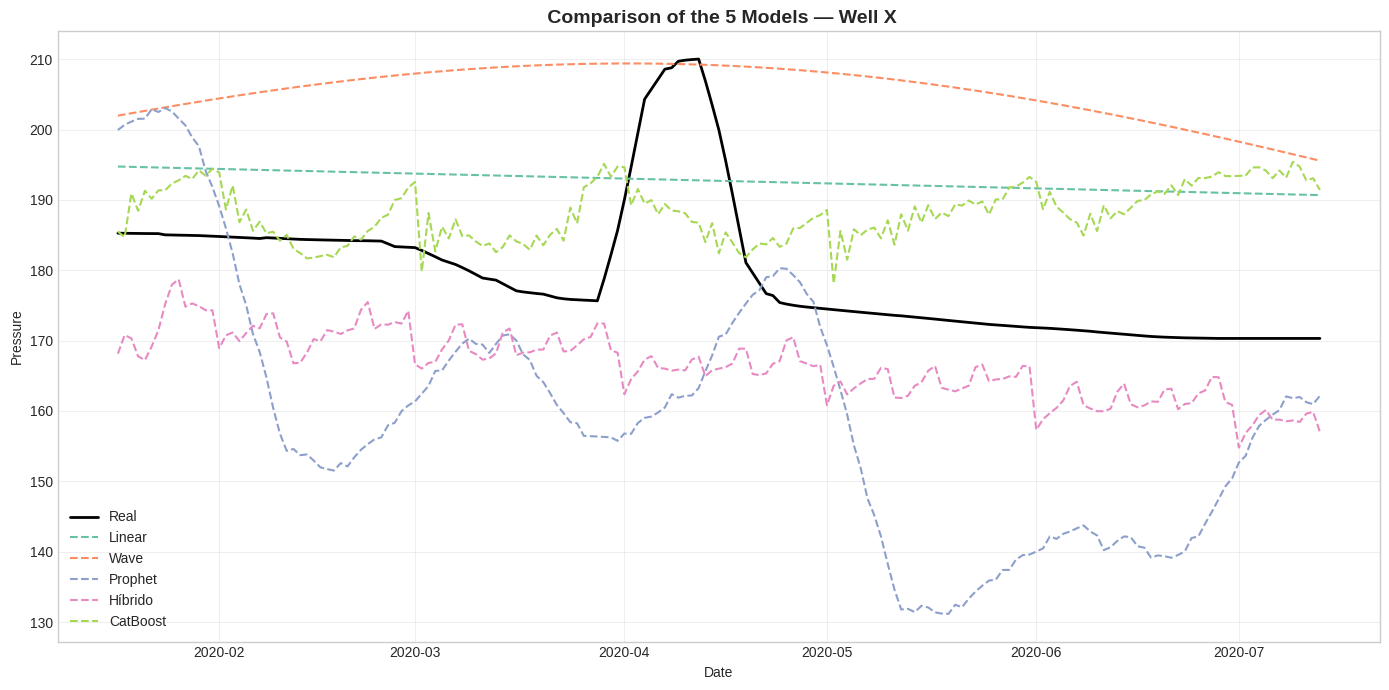

In [ ]:
poco_alvo = "SPH-6"

df_lstm_poco = df_lstm[df_lstm["poco"] == poco_alvo].copy()
df_lstm_poco["dates"] = pd.to_datetime(df_lstm_poco["dates"])

df_prophet_poco = df_prophet[df_prophet["poco"] == poco_alvo].iloc[0]

dates_prophet = df_prophet_poco["test_dates"]
y_true = df_prophet_poco["y_true"]
y_prophet = df_prophet_poco["yhat_prophet"]
y_hibrido = df_prophet_poco["yhat_hibrido"]
y_cat = df_prophet_poco["yhat_cat"]

plt.figure(figsize=(14, 7))
plt.plot(df_lstm_poco["dates"], df_lstm_poco["y_true"], label="Real", color="black", linewidth=2)

plt.plot(df_lstm_poco["dates"], df_lstm_poco["yhat_linear"], label="Linear", linestyle="--")
plt.plot(df_lstm_poco["dates"], df_lstm_poco["yhat_wave"], label="Wave", linestyle="--")


plt.plot(dates_prophet, y_prophet, label="Prophet", linestyle="--")
plt.plot(dates_prophet, y_hibrido, label="Híbrido", linestyle="--")
plt.plot(dates_prophet, y_cat, label="CatBoost", linestyle="--")

plt.title(f" Comparison of the 5 Models — Well X", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Pressure")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("grafico_modelos.jpg", dpi=600, format="jpg", bbox_inches='tight')
plt.show()


/tmp/ipython-input-3334641946.py:91: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3334641946.py:93: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.savefig(output_file, dpi=300)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


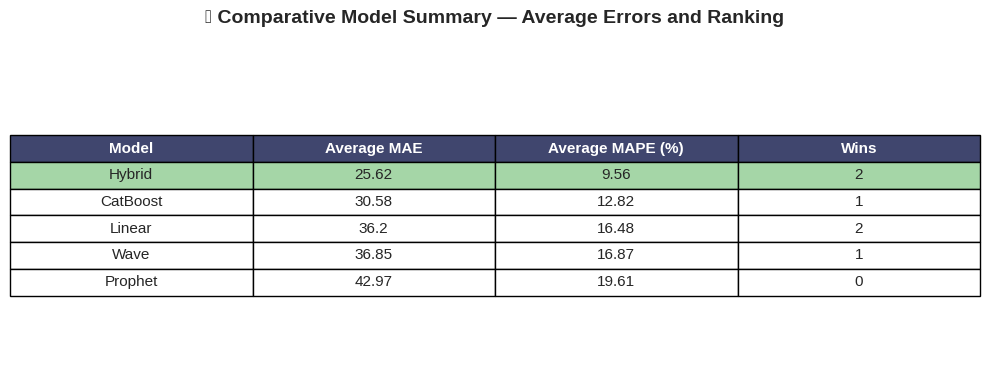

✅ Summary saved as image at: model_summary.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_lstm_metrics = pd.read_csv("/content/resultados_lstm_predicao_futura.csv")
df_prophet_metrics = pd.read_csv("/content/resultados_prophet_hibrido_catboost.csv")



df_prophet_metrics = df_prophet_metrics[[
    "poco", "Prophet_MAE", "Hibrido_MAE", "CatBoost_MAE",
    "Prophet_MAPE", "Hibrido_MAPE", "CatBoost_MAPE"
]]

df_lstm_metrics = df_lstm_metrics[[
    "poco", "Linear_MAE", "Wave_MAE",
    "Linear_MAPE", "Wave_MAPE"
]]



df = pd.merge(df_lstm_metrics, df_prophet_metrics, on="poco")


mae_cols = [c for c in df.columns if "_MAE" in c]
mape_cols = [c for c in df.columns if "_MAPE" in c]
model_names = [c.replace("_MAE", "") for c in mae_cols]


mae_means = df[mae_cols].mean().round(2)
mape_means = df[mape_cols].mean().round(2)

ranking = df[["poco"] + mae_cols].melt(
    id_vars="poco", var_name="model", value_name="mae"
)
ranking["model"] = ranking["model"].str.replace("_MAE", "")
best_models = ranking.loc[ranking.groupby("poco")["mae"].idxmin()]
ranking_count = best_models["model"].value_counts()

# 📊 Build final summary DataFrame
summary = pd.DataFrame({
    "Model": model_names,
    "Average MAE": mae_means.values,
    "Average MAPE (%)": mape_means.values,
    "Wins": [ranking_count.get(m, 0) for m in model_names]
})
summary["Model"] = summary["Model"].replace({"Hibrido": "Hybrid"})

#  Sort by average MAE
summary = summary.sort_values("Average MAE").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')


highlight = summary["Average MAE"] == summary["Average MAE"].min()


table = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc='center',
    loc='center'
)


table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)


for j in range(len(summary.columns)):
    cell = table[0, j]
    cell.set_facecolor('#40466e')
    cell.set_text_props(weight='bold', color='white')


best_idx = summary["Average MAE"].idxmin()
for j in range(len(summary.columns)):
    table[best_idx + 1, j].set_facecolor('#a5d6a7')  # light green

# Save imagem
plt.title(
    "📊 Comparative Model Summary — Average Errors and Ranking",
    fontsize=14, weight='bold', pad=20
)
plt.tight_layout()
output_file = "model_summary.png"
plt.savefig(output_file, dpi=300)
plt.show()

print(f"✅ Summary saved as image at: {output_file}")


/tmp/ipython-input-1473985561.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


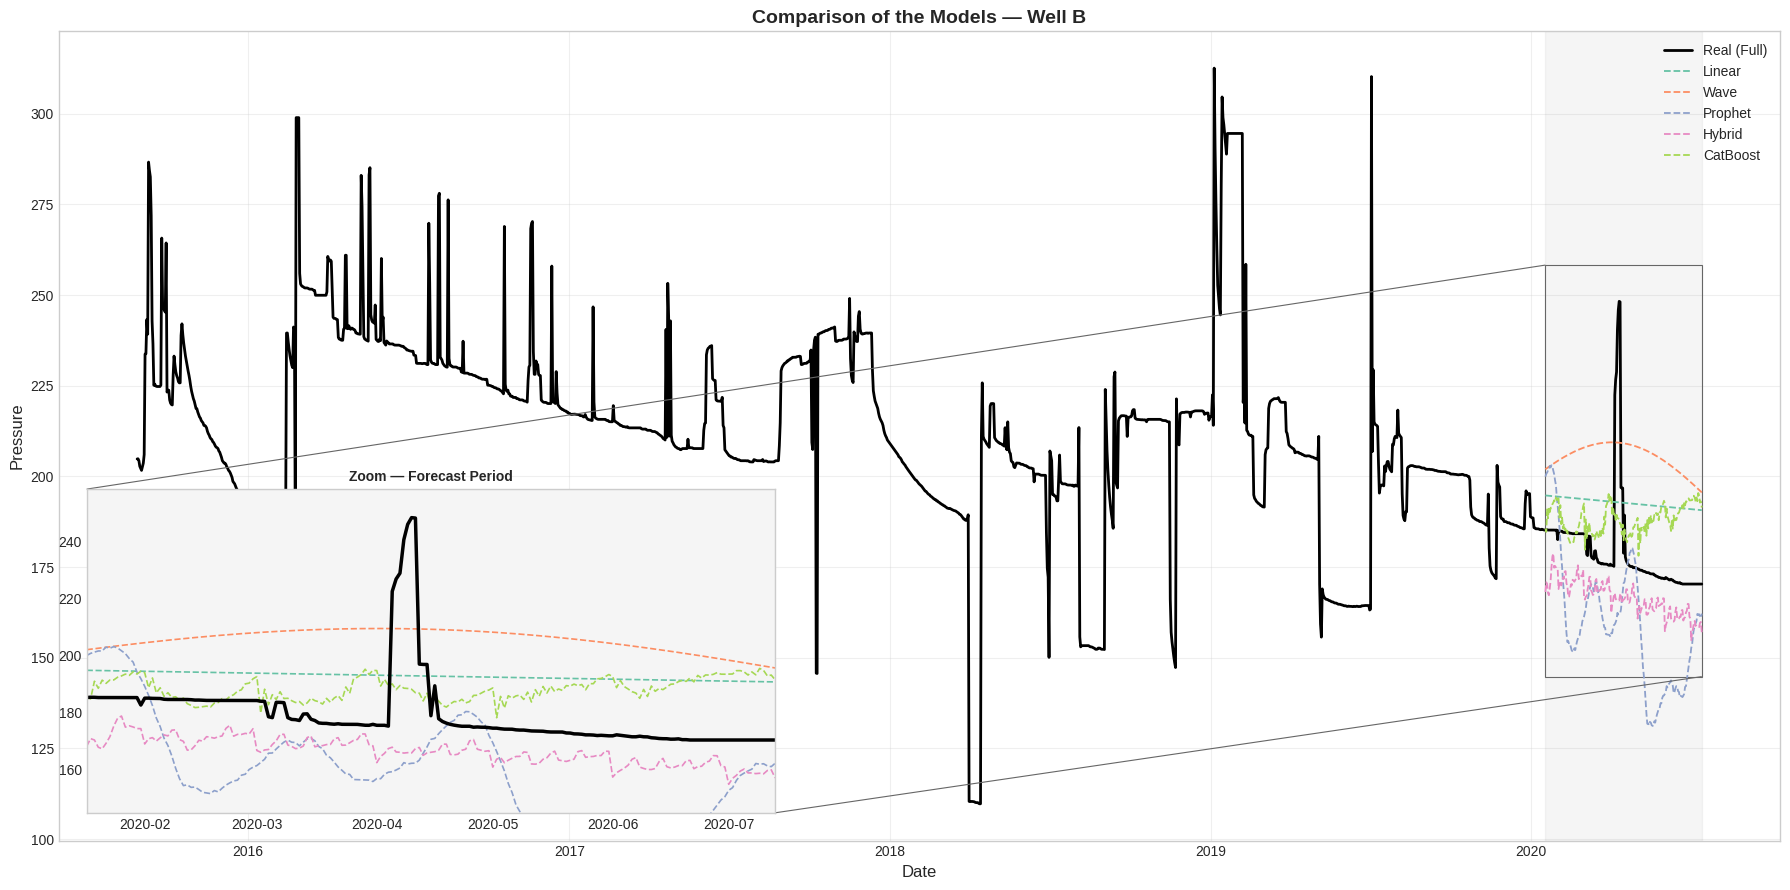

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import re


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")


WELL_NAME    = "SPH-6"
PARAMETER    = "TPT-P"
TIME_COL     = "datetime"
FREQ         = "D"
AGG          = "median"


def load_series(filepath, col_time, col_value, do_resample=True, freq="D", agg="median"):
    df = pd.read_csv(filepath)
    if col_time not in df.columns:
        candidates = [c for c in df.columns if any(k in c.lower() for k in ["time","data","date","datetime","timestamp"])]
        col_time = candidates[0]
    df[col_time] = pd.to_datetime(df[col_time], errors="coerce")
    df = df.dropna(subset=[col_time])
    if col_value not in df.columns:
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if col_time in num_cols:
            num_cols.remove(col_time)
        col_value = num_cols[0]
    df = df[[col_time, col_value]].dropna()
    df = df.rename(columns={col_time: "ds", col_value: "y"})
    df = df.sort_values("ds").drop_duplicates(subset=["ds"]).set_index("ds")
    if do_resample:
        if   agg == "mean": df = df.resample(freq).mean()
        elif agg == "sum" : df = df.resample(freq).sum()
        else              : df = df.resample(freq).median()
    df["y"] = df["y"].interpolate(method="time").bfill().ffill()
    return df.reset_index()

def clean_float_list(text):
    if pd.isna(text): return []
    text = re.sub(r'np\.float64\(', '', text)
    text = text.replace(')', '')
    return [float(x) for x in text.strip("[]").split(",") if x.strip()]

def clean_timestamp_list(text):
    if pd.isna(text): return []
    text = re.sub(r"Timestamp\('", '', text)
    text = text.replace("')", '')
    return [pd.to_datetime(x.strip()) for x in text.strip("[]").split(",") if x.strip()]

# ===============================
# Load séries
# ===============================
RAW_DATA_PATH = "/content/SPH-6.csv"
df_real = load_series(RAW_DATA_PATH, TIME_COL, PARAMETER, do_resample=True, freq=FREQ, agg=AGG)

# ===============================
# Prophet / Hybrid / CatBoost
# ===============================
df_ph = pd.read_csv("resultados_prophet_hibrido_catboost.csv")
df_ph["y_true"]        = df_ph["y_true"].apply(clean_float_list)
df_ph["yhat_prophet"]  = df_ph["yhat_prophet"].apply(clean_float_list)
df_ph["yhat_hibrido"]  = df_ph["yhat_hibrido"].apply(clean_float_list)
df_ph["yhat_cat"]      = df_ph["yhat_cat"].apply(clean_float_list)
df_ph["test_dates"]    = df_ph["test_dates"].apply(clean_timestamp_list)

row = df_ph[df_ph["poco"] == WELL_NAME].iloc[0]
dates_test   = pd.to_datetime(row["test_dates"])
y_true_test  = np.array(row["y_true"])
y_prophet    = np.array(row["yhat_prophet"])
y_hybrid     = np.array(row["yhat_hibrido"])
y_cat        = np.array(row["yhat_cat"])

df_test_clock = pd.DataFrame({"ds": dates_test})

# ===============================
# Linear / Wave
# ===============================
df_lw = pd.read_csv("previsoes_linear_wave_lstm_TODOS.csv")
df_lw = df_lw[df_lw["poco"] == WELL_NAME].copy()
df_lw["dates"] = pd.to_datetime(df_lw["dates"])

df_lw_align = df_test_clock.merge(
    df_lw[["dates","yhat_linear","yhat_wave"]].rename(columns={"dates":"ds"}),
    on="ds", how="left"
)

y_linear = df_lw_align["yhat_linear"].to_numpy()
y_wave   = df_lw_align["yhat_wave"].to_numpy()

# ===============================
# Plot
# ===============================
fig, ax = plt.subplots(figsize=(18, 9))

# Shade forecast region
ax.axvspan(dates_test.min(), dates_test.max(), color="gray", alpha=0.08)

# Real complete
ax.plot(df_real["ds"], df_real["y"], color="black", linewidth=2, label="Real (Full)")

# Forecasts (main chart)
ax.plot(dates_test, y_linear,  "--", label="Linear", linewidth=1.3)
ax.plot(dates_test, y_wave,    "--", label="Wave", linewidth=1.3)
ax.plot(dates_test, y_prophet, "--", label="Prophet", linewidth=1.3)
ax.plot(dates_test, y_hybrid,  "--", label="Hybrid", linewidth=1.3)
ax.plot(dates_test, y_cat,     "--", label="CatBoost", linewidth=1.3)

# ===============================
# 🔍 Inset Zoom (forecast period)
# ===============================
axins = inset_axes(ax, width="40%", height="40%", loc='lower left', borderpad=2)


# Plot on zoom
axins.axvspan(dates_test.min(), dates_test.max(), color="gray", alpha=0.08)
axins.plot(dates_test, y_linear,  "--", linewidth=1.2)
axins.plot(dates_test, y_wave,    "--", linewidth=1.2)
axins.plot(dates_test, y_prophet, "--", linewidth=1.2)
axins.plot(dates_test, y_hybrid,  "--", linewidth=1.2)
axins.plot(dates_test, y_cat,     "--", linewidth=1.2)
axins.plot(df_real["ds"], df_real["y"], color="black", linewidth=2.5)

# Limits for zoom (exact test range)
axins.set_xlim(dates_test.min(), dates_test.max())
y_min = min(np.nanmin(y_true_test), np.nanmin(y_cat), np.nanmin(y_hybrid))
y_max = max(np.nanmax(y_true_test), np.nanmax(y_prophet), np.nanmax(y_wave))
axins.set_ylim(y_min - 10, y_max + 10)

# Annotation
axins.set_title("Zoom — Forecast Period", fontsize=10, fontweight="bold")
axins.grid(False)

# Mark zoom connection
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4", lw=0.8)

# ===============================
# ✨ Final Touches
# ===============================
ax.set_title(f"Comparison of the Models — Well B", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Pressure", fontsize=12)
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("final_forecast_zoom_EN.jpg", dpi=600, bbox_inches="tight")
plt.show()
